<class 'numpy.ndarray'> float64
<class 'numpy.ndarray'> float64
(353, 10) (353,)
(89, 10) (89,)
10
Iteration 100 : Loss 5376.7763
Iteration 200 : Loss 4874.9675
Iteration 300 : Loss 4501.8340
Iteration 400 : Loss 4220.6918
Iteration 500 : Loss 4005.7337
Iteration 600 : Loss 3838.7601
Iteration 700 : Loss 3706.8965
Iteration 800 : Loss 3601.0007
Iteration 900 : Loss 3514.5497
Iteration 1000 : Loss 3442.8620
Iteration 1100 : Loss 3382.5536
Iteration 1200 : Loss 3331.1577
Iteration 1300 : Loss 3286.8577
Iteration 1400 : Loss 3248.3003
Iteration 1500 : Loss 3214.4641
Iteration 1600 : Loss 3184.5669
Iteration 1700 : Loss 3158.0002
Iteration 1800 : Loss 3134.2835
Iteration 1900 : Loss 3113.0304
Iteration 2000 : Loss 3093.9259
Iteration 2100 : Loss 3076.7092
Iteration 2200 : Loss 3061.1610
Iteration 2300 : Loss 3047.0951
Iteration 2400 : Loss 3034.3514
Iteration 2500 : Loss 3022.7912
Iteration 2600 : Loss 3012.2930
Iteration 2700 : Loss 3002.7502
Iteration 2800 : Loss 2994.0683
Iteration 2900

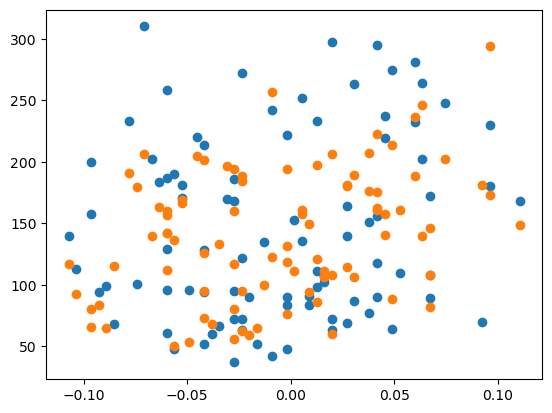

In [18]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data
df_y = data.target

import numpy as np

X = np.array(df_X)

print(type(X), X.dtype)

y = np.array(df_y)

print(type(y), y.dtype)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

LEARNING_RATE = 0.1 #0.001부터 테스트, 속도에 가까움

losses = []

for i in range(1, 10001): # 학습데이터 반복횟수를 증가시킴 LEARNING_RATE와 비율 조절을 잘 해야함
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

In [21]:
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse #MSE 3000 이하면 자동으로 RMSE는 150 이하

np.float64(2880.241873306518)